In [1]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['pdf.fonttype'] = 42

In [27]:
te_df = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\ML performance comparison\Results\64\RF-2\metrics_64.csv")

In [28]:
te_df.head()

,all_mcc,all_acc,all_auc,all_f1,all_pre,all_se,all_sp,all_Youden_Index
0,0.459929,0.723354,0.788921,0.658277,0.805687,0.5565,0.8767,0.445767
1,0.456874,0.722571,0.788478,0.659615,0.799534,0.5614,0.8707,0.437675
2,0.451394,0.719436,0.783096,0.653772,0.799054,0.5532,0.8722,0.431212


In [29]:
auc = te_df['all_auc'].tolist()
acc = te_df['all_acc'].tolist()
mcc = te_df['all_mcc'].tolist()
f1 = te_df['all_f1'].tolist()
pre = te_df['all_pre'].tolist()
se = te_df['all_se'].tolist()
sp = te_df['all_sp'].tolist()
yi = te_df['all_Youden_Index'].tolist()

In [30]:
scores = {
    'AUC':auc,
    'Accuracy':acc,
    'MCC':mcc,
    'F1':f1,
    'Precision':pre,
    'Sensitivity':se,
    'Specificity':sp,
    'Youden_Index':yi
}
scores

{'AUC': [0.788921157, 0.788478151, 0.783095628],
 'Accuracy': [0.723354232, 0.722570533, 0.719435737],
 'MCC': [0.459929371, 0.456874144, 0.451393776],
 'F1': [0.658276864, 0.659615385, 0.65377176],
 'Precision': [0.805687204, 0.7995338, 0.799054374],
 'Sensitivity': [0.5565, 0.5614, 0.5532],
 'Specificity': [0.8767, 0.8707, 0.8722],
 'Youden_Index': [0.445767446, 0.437675203, 0.431212237]}

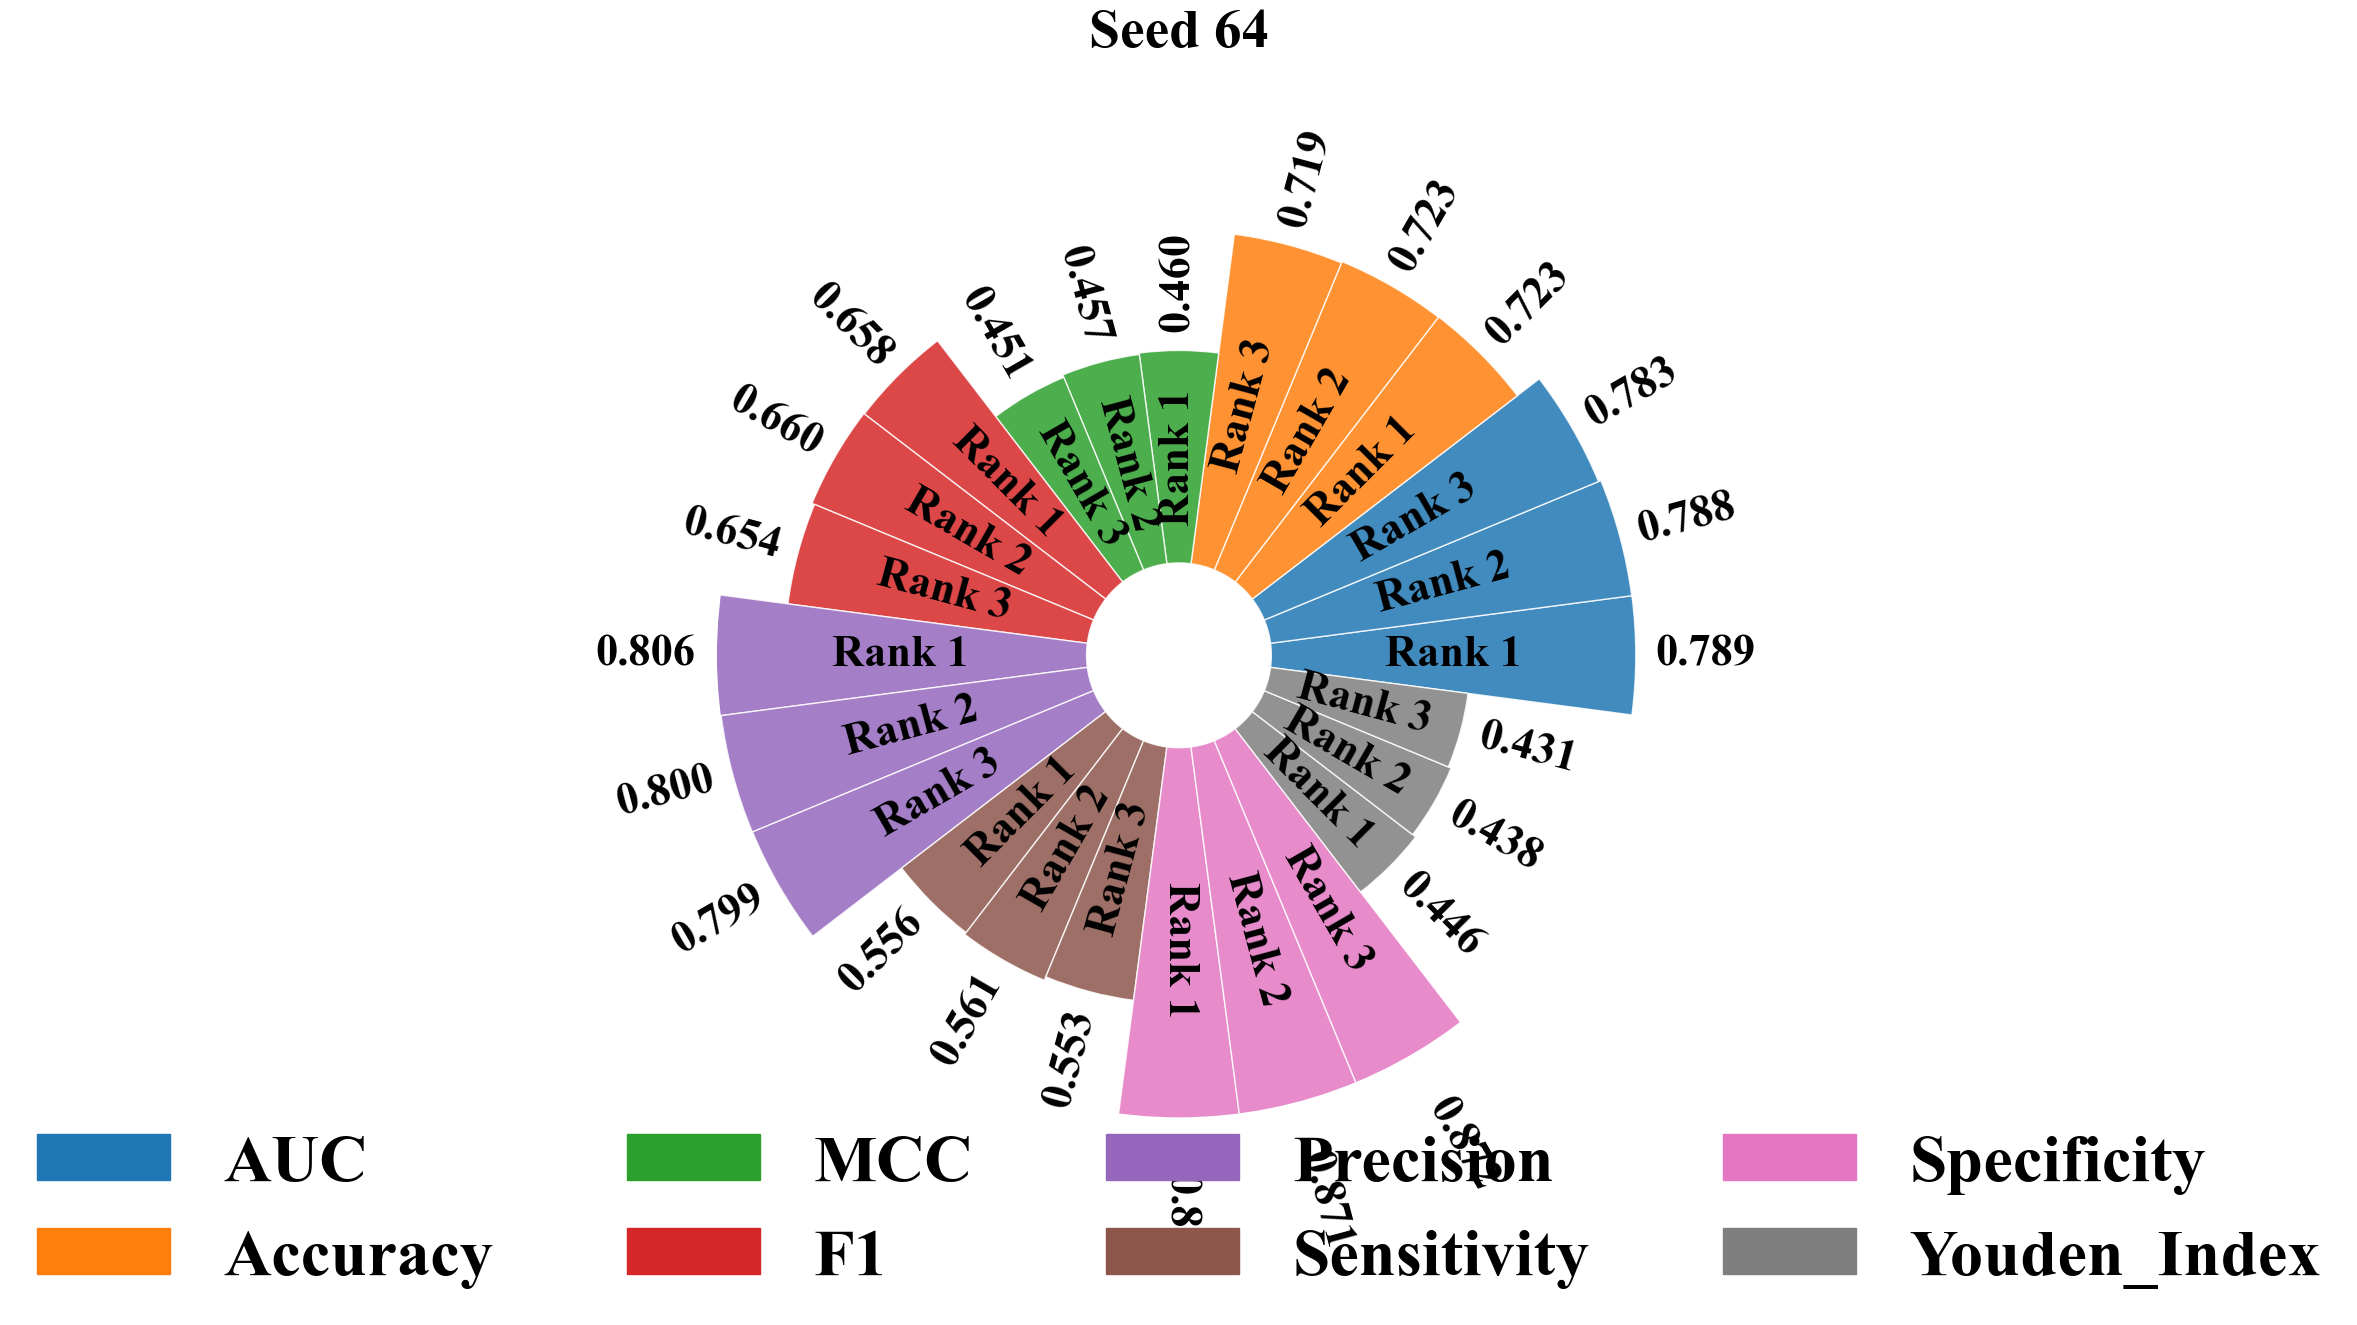

In [31]:
metrics = [
    'AUC', 'Accuracy', 'MCC', 'F1', 'Precision', 'Sensitivity', 'Specificity', 
    'Youden_Index'
]

models = ['Rank 1', 'Rank 2', 'Rank 3']

scores = scores

colors = {m: plt.cm.tab10(i % 10) for i, m in enumerate(metrics)}

num_metrics = len(metrics)
num_models = len(models)
width = 2 * np.pi / (num_metrics * num_models)

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))
plt.title("Seed 64", fontsize=40, fontweight='bold', y=1.15)

bottom = 0.2 

for i, metric in enumerate(metrics):
    values = scores[metric]
    color = colors[metric]

    for j, val in enumerate(values):
        theta = (i * num_models + j) * width
        
        bar = ax.bar(theta, 
                     val, 
                     width=width*1, 
                     color=color, 
                     alpha=0.85,
                     bottom=0.2, 
                     edgecolor='white', 
                     linewidth=1)

        rotation = np.degrees(theta)
        if 90 < rotation < 270:
            rotation += 180
            ha = 'right'
        else:
            ha = 'left'

        ax.text(theta, bottom + val/2, models[j],
                ha='center', va='center',
                rotation=rotation,
                rotation_mode='anchor',
                fontweight='bold',
                fontsize=32,
                color='black')

        ax.text(theta, 
                bottom + val + 0.15, 
                f"{val:.3f}",
                ha='center', va='center',
                rotation=rotation,
                rotation_mode='anchor',
                fontweight='bold',
                fontsize=32,
                color='black')

ax.set_ylim(0, 1.0)  
ax.set_yticklabels([])
ax.set_xticks([])


ax.grid(False)

ax.spines['polar'].set_visible(False)

legend_patches = [Patch(color=colors[m], label=m) for m in metrics]
plt.legend(handles=legend_patches,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.25),
           ncol=4,
           prop={'size':48, 'weight':'bold'},
           frameon=False)

plt.savefig("Metrics_Seed_64.pdf", format='pdf', bbox_inches='tight')

plt.show()